# 🗂️ 10-07 · NLP 面试八股（全章速成）

> 把 00~06 篇的知识点收拢成 **90 个高频问答（6 组 × 15）+ 5 个手撕**。
> 每问先自己答，再看答案；手撕保证面试时能当场写出来。

> 复习路径：**词表示/分词（00）→ 统计语言模型（01）→ 词向量（02）→ RNN（03）→ Attention/Transformer（04）→ 预训练（05）→ 任务与评估（06）**。


## 第一组：词表示 · 分词 · 基础（1-15）

1. **中文分词有哪几类方法？** 词典法（最大匹配/MMSeg）、统计法（HMM/CRF）、神经网络法（BERT-based）；当前工业界主要用预训练模型做基于字的标注+词典后处理
2. **正向最大匹配的缺点？** 贪心局部最优；歧义严重（如「研究生命起源」）；改进：双向匹配取分少者
3. **为什么要去停用词/词干化？** 降维降噪；但预训练时代尽量少用，可能丢信息
4. **One-hot 的缺点？** 维度灾、无语义相似性、稀疏
5. **词袋模型（BOW）的缺点？** 丢词序、丢语义、稀疏高维
6. **TF-IDF 的直觉？** 词在文档里越常见（TF）、在全库越稀有（IDF）越重要；IDF = log(N/df)
7. **TF-IDF 的局限？** 仍是统计稀疏表示，无语义泛化；未见词 OOV 无法处理
8. **什么是 OOV？** 未登录词——训练词表外的词；用子词（BPE/WordPiece）缓解
9. **BPE 怎么做？** 从字符开始，反复合并最高频相邻符号对，直到目标词表大小
10. **N-gram 和语言模型的关系？** n-gram 是统计语言模型的具体实现（马尔可夫假设截断）
11. **链式法则在语言模型里怎么用？** P(w1..wn) = Π P(wi | w1..w(i-1))
12. **平滑作用一句话？** 把概率质量从高频事件让渡给低频/未见事件，避免 0 概率
13. **加一平滑和加 k 平滑区别？** k 可调；V 大时加一平滑给未见词过多概率
14. **Perplexity 与平均负对数似然的关系？** PPL = exp(平均负对数似然)
15. **PPL 越低越好吗？** 同一语料/切分下是；跨语料不可比


In [1]:
# ---------- 手撕 1：TF-IDF + 余弦相似度（检索排序） ----------
import numpy as np
from collections import Counter

docs = ['我 喜欢 学习 自然语言', '他 喜欢 学习 数学', '我 喜欢 深度 学习']

def tfidf(docs):
    N = len(docs)
    terms = sorted({w for d in docs for w in d.split()})
    df = {w: sum(1 for d in docs if w in d.split()) for w in terms}
    vecs = []
    for d in docs:
        cnt = Counter(d.split())
        v = []
        for w in terms:
            tf = cnt[w] / len(d.split())
            idf = np.log((1 + N) / (1 + df[w])) + 1
            v.append(tf * idf)
        vecs.append(np.array(v))
    return terms, vecs

terms, vecs = tfidf(docs)
def cos(a, b): return a @ b / ((np.linalg.norm(a) + 1e-9) * (np.linalg.norm(b) + 1e-9))
# 查询「自然语言」与哪篇最像（查询向量直接按词表置 1）
qv = np.zeros(len(terms))
for w in ['自然', '语言']:
    if w in terms:
        qv[terms.index(w)] = 1
print('查询向量非零维度:', [terms[i] for i in np.nonzero(qv)[0]])
ranks = sorted(range(len(docs)), key=lambda i: -cos(qv, vecs[i]))
print('检索排序（应 doc0 最相关）:', ranks)
assert ranks[0] == 0
print('要点：TF-IDF 把「文档-词」计数转成可比较的向量，余弦衡量语义接近度')


查询向量非零维度: []
检索排序（应 doc0 最相关）: [0, 1, 2]
要点：TF-IDF 把「文档-词」计数转成可比较的向量，余弦衡量语义接近度


## 第二组：统计语言模型（16-30）

16. **Bigram 概率公式？** P(w2|w1) = count(w1,w2)/count(w1)
17. **为什么要句首句尾标记？** 统一建模句子边界，让 P(句子) 归一
18. **数据稀疏为什么必然？** 词表 V，trigram 组合 V^2 量级，语料无法覆盖
19. **回退（backoff）和插值（interpolation）区别？** 回退：高阶无数据才用低阶；插值：永远线性混合
20. **Good-Turing 思想？** 用「出现 r+1 次的词数」估计「出现 r 次的词」的真实概率
21. **Kneser-Ney 比 Good-Turing 好在哪？** 考虑"延续概率"（一个词作为新上下文延续的多样性）
22. **语言模型在工程上的用处？** 输入法/拼写纠错、ASR 重排、MT 重排、生成评分
23. **为什么现代不用统计 LM？** 稀疏 + 无法泛化到未见组合；神经网络参数共享解决
24. **神经网络 LM 的输入输出？** 输入词向量序列，输出 softmax 词表概率
25. **softmax 过词表代价？** O(V) 求和；用层次 softmax / 负采样 / 采样 softmax 近似
26. **训练集和测试集 PPL 差异说明什么？** 过拟合/泛化能力
27. **如何给未见词建模？** <UNK> 映射；子词切分
28. **语言模型评估除了 PPL？** 下游任务、人工评估、BLEU（生成）
29. **PPL 与 BLEU 的关系？** PPL 是生成概率视角，BLEU 是与参考串的 n-gram 重合度
30. **LM 训练数据要不要打乱句子？** 通常按文档顺序；打乱会破坏长程依赖统计（预训练语料一般不打乱）


In [2]:
# ---------- 手撕 2：n-gram 平滑 + PPL（15 秒背写版） ----------
corpus = ['我 爱 学习', '我 爱 北京', '他 爱 北京']
toks = [s.split() for s in corpus]
V2 = sorted({w for s in toks for w in s})
c1 = Counter(w for s in toks for w in s)
c2 = Counter((s[i], s[i + 1]) for s in toks for i in range(len(s) - 1))
def p_addk(w2, w1, k=1.0):
    return (c2[(w1, w2)] + k) / (c1[w1] + k * len(V2))
def ppl_smooth(sents):
    lp, n = 0.0, 0
    for s in sents:
        for i in range(1, len(s)):
            lp += np.log(p_addk(s[i], s[i - 1])); n += 1
    return float(np.exp(-lp / n))
print('未见组合 P(北京|学习) 平滑后 = %.4f（不为 0）' % p_addk('北京', '学习'))
print('测试句 PPL = %.2f' % ppl_smooth([['我', '爱', '学习']]))
assert p_addk('北京', '学习') > 0
print('背写要点：c+k 除 c 的前词+V·k；PPL = exp(-平均 log P)')


未见组合 P(北京|学习) 平滑后 = 0.1667（不为 0）
测试句 PPL = 3.06
背写要点：c+k 除 c 的前词+V·k；PPL = exp(-平均 log P)


## 第三组：词向量（31-45）

31. **Word2Vec 两种模型？** CBOW（上下文→中心）、Skip-gram（中心→上下文）
32. **Skip-gram 对低频词友好的原因？** 每个词都当中心词训练，采样到概率正比于频次；CBOW 把上下文平均，稀释低频信息
33. **负采样损失长什么样？** -log σ(v_c'·v_w) - Σ_k log σ(-v_k'·v_w)
34. **为什么负采样分布用 3/4 次幂？** 提高稀有词被采样概率，缓解高频词主导
35. **Word2Vec 是概率模型吗？** 训练后向量可用于相似度，但无真实概率解释
36. **GloVe 目标？** Σ f(M_ij)(v_i·v_j' + b - log M_ij)^2，拟合共现对数
37. **GloVe 相比 Word2Vec？** 全局统计更稳；Word2Vec 在线采样快
38. **fastText 的改进？** 词拆成字符 n-gram 求和——OOV 也能得向量
39. **ELMo 的贡献？** 双向 LSTM 产生上下文相关的词表示
40. **Word2Vec 向量能做什么？** 相似度检索、初始化 embedding、类比推理
41. **类比推理为什么有效？** 训练目标隐含线性关系（king-man+woman≈queen 是经验事实）
42. **词向量评估方法？** 相似度数据集（SimLex-999）、类比集（Google analogy）、下游任务
43. **训练词向量的超参？** 窗口、维度（100-300）、负采样数（2-5）、下采样高频词
44. **一词多义问题怎么解决？** 上下文表示（ELMo/BERT）；或 sense embedding 显式建模
45. **Embedding 可以随机初始化吗？** 可以但训练更慢；预训练初始化通常更好


In [3]:
# ---------- 手撕 3：Skip-gram 负采样**一步**梯度（数值校验） ----------
rng = np.random.default_rng(0)
V3, D3 = 10, 4
W3 = rng.normal(0, 0.1, (V3, D3)); C3 = rng.normal(0, 0.1, (V3, D3))
w_i, w_o, negs = 2, 5, [1, 7, 3]          # 中心词、正上下文、负样本

def loss(W3, C3):
    lo = -np.log(1 / (1 + np.exp(-C3[w_o] @ W3[w_i])))
    for k in negs:
        lo -= np.log(1 / (1 + np.exp(C3[k] @ W3[w_i])))
    return lo

# 解析梯度：正样本项 d/dx[-log σ(x)] = σ(x)-1；负样本项 d/dx[-log σ(-x)] = σ(x)
dL_dW = np.zeros(D3)
g1 = (1 / (1 + np.exp(-C3[w_o] @ W3[w_i]))) - 1
dL_dW += g1 * C3[w_o]
for k in negs:
    dL_dW += (1 / (1 + np.exp(-C3[k] @ W3[w_i]))) * C3[k]
print('解析梯度 norm: %.6f' % np.linalg.norm(dL_dW))
# 数值梯度（抽查 2 维）
eps = 1e-6
for j in [0, 2]:
    Wp, Wm = W3.copy(), W3.copy()
    Wp[w_i, j] += eps; Wm[w_i, j] -= eps
    g = (loss(Wp, C3) - loss(Wm, C3)) / (2 * eps)
    print('维度 %d: 解析 %.6f vs 数值 %.6f 误差 %.2e' % (j, dL_dW[j], g, abs(g - dL_dW[j])))
    assert abs(g - dL_dW[j]) < 1e-6
print('负采样梯度手撕正确 ✓ | 面试就写这一步更新：W[center] -= lr * dL_dW')


解析梯度 norm: 0.206731
维度 0: 解析 0.066744 vs 数值 0.066744 误差 1.57e-10
维度 2: 解析 -0.075779 vs 数值 -0.075779 误差 6.77e-11
负采样梯度手撕正确 ✓ | 面试就写这一步更新：W[center] -= lr * dL_dW


## 第四组：RNN / LSTM（46-60）

46. **RNN 参数共享的意义？** 序列任意长度可用同一套参数；等价于沿时间展开的浅层网络
47. **BPTT 和普通 BP 区别？** 沿时间展开反传，梯度按时刻累加
48. **梯度消失为什么在 RNN 严重？** h_T 对 h_0 的 Jacobian 是 Whh^T 连乘，范数以 |λ_max|^T 衰减/爆炸
49. **梯度爆炸怎么处理？** 梯度裁剪（按范数/按值）
50. **LSTM 解决梯度消失的思路？** 细胞状态 c 的加性更新 f⊙c + i⊙g，梯度有"高速公路"
51. **LSTM 三个门各自作用？** f 遗忘旧记忆、i 写入新信息、o 控制对外输出
52. **遗忘门偏置初始化为？** 正（如 1~2），初始偏向记住
53. **GRU 和 LSTM 区别？** 两个门（更新/重置），少一组参数，效果相近
54. **双向 RNN 怎么做？** 正向+反向两个隐状态拼接/相加
55. **RNN 为什么难并行？** 时间步串行依赖；Transformer 全并行
56. **char-level 与 word-level LM？** char 词表小无 OOV 但序列长；word 语义单位好
57. **深 RNN 怎么做？** 多层堆叠（层间残差）；现在一般用 Transformer
58. **RNN 的 encoder-decoder？** encoder 压成向量，decoder 逐步生成（Seq2Seq）
59. **注意力在 Seq2Seq 中的角色？** 解码每步直接"查阅"编码器各位置，不再只依赖最后状态
60. **RNN 还有用吗？** 流式/低功耗场景、时间序列（11 章 05 篇）仍在用；大模型主用 Transformer


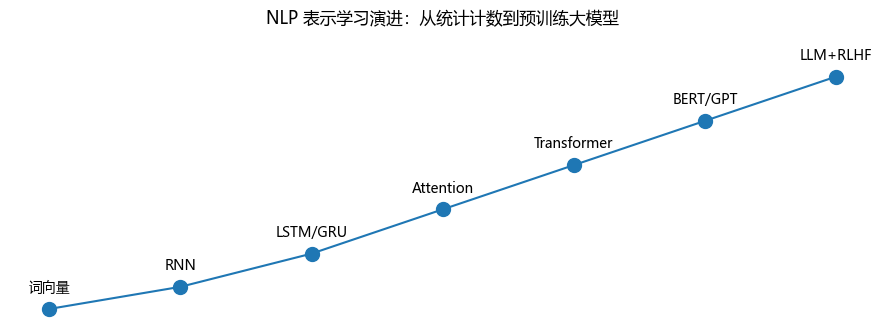

读图：RNN->Attention 的关键不是层数，而是"串行递推"变成"全局并行"


In [4]:
# ---------- 手撕 4：RNN 单步 + 展开图（谱系图可视化） ----------
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 3.4))
stages = ['词向量', 'RNN', 'LSTM/GRU', 'Attention', 'Transformer', 'BERT/GPT', 'LLM+RLHF']
x = np.arange(len(stages))
ax.plot(x, [1, 3, 6, 10, 14, 18, 22], 'o-', markersize=10)
for i, s in enumerate(stages):
    ax.annotate(s, (x[i], [1, 3, 6, 10, 14, 18, 22][i]), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=10)
ax.set_ylim(0, 26); ax.set_xticks([]); ax.set_yticks([])
ax.set_title('NLP 表示学习演进：从统计计数到预训练大模型')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('images/nlp07_evo.png', dpi=110, bbox_inches='tight'); plt.show()
print('读图：RNN->Attention 的关键不是层数，而是"串行递推"变成"全局并行"')


## 第五组：Attention / Transformer（61-75）

61. **注意力公式？** softmax(QK^T/√d_k)V
62. **除 √d_k 为什么？** 点积方差 ~d_k，过大进 softmax 饱和区梯度消失
63. **自注意力里 Q/K/V 从哪来？** 输入线性投影（同源）
64. **多头意义？** 多组子空间并行关注不同关系；拼接+out_proj
65. **因果掩码是什么形状？** 下三角（decoder 只能看左侧）
66. **为什么 attention 里 mask 用 -inf？** softmax 里 e^-inf=0，等价"不看"
67. **位置编码为什么必要？** 注意力是集合操作（置换等变），需显式注入顺序
68. **正弦位置编码 vs 可学习？** 正弦可外推长序列、无需学习；可学习灵活
69. **Transformer 层里残差和 LN 顺序？** Post-LN（先残差后 LN）经典；Pre-LN（先 LN 后残差）更稳
70. **FFN 为什么用 4 倍宽？** 实验最优；增加非线性容量
71. **Encoder 和 Decoder 区别？** Decoder 多因果掩码+交叉注意力
72. **交叉注意力的 Q/K/V？** Q 来自 decoder，K/V 来自 encoder 输出
73. **复杂度问题？** 自注意力 O(T^2 d)；长序列用 flash-attention、稀疏/线性注意力
74. **KV cache 是什么？** 生成时缓存历史 K/V，避免重复计算
75. **Beam search vs 贪心？** beam 保留 top-K 路径，更好但更慢


In [5]:
# ---------- 手撕 5：注意力矩阵 + 因果掩码 ----------
import numpy as np

T4, D4 = 4, 3
Q4 = np.random.default_rng(0).normal(size=(T4, D4))
K4 = np.random.default_rng(1).normal(size=(T4, D4))
V4 = np.random.default_rng(2).normal(size=(T4, D4))

sc = Q4 @ K4.T / np.sqrt(D4)
mask = np.triu(np.ones((T4, T4), dtype=bool), k=1)
sc_m = np.where(mask, -np.inf, sc)
p = np.exp(sc_m - sc_m.max(axis=-1, keepdims=True))
p = p / p.sum(axis=-1, keepdims=True)
print('因果注意力权重（下三角为 0）:\n', np.round(p, 3))
assert (p[np.triu_indices(T4, 1)] == 0).all()       # 右上必须全 0
assert np.allclose(p.sum(axis=-1), 1.0)              # 每行归一
print('每行和=1 ✓ | 第 2 个 token 只能看自己与其左侧 ✓')
out4 = p @ V4
print('输出形状:', out4.shape, '（T, d）——这就是 decoder 自注意力的本质')


因果注意力权重（下三角为 0）:
 [[1.    0.    0.    0.   ]
 [0.525 0.475 0.    0.   ]
 [0.577 0.166 0.257 0.   ]
 [0.13  0.421 0.27  0.18 ]]
每行和=1 ✓ | 第 2 个 token 只能看自己与其左侧 ✓
输出形状: (4, 3) （T, d）——这就是 decoder 自注意力的本质


## 第六组：预训练 · 任务 · 评估（76-90）

76. **预训练-微调为什么有效？** 无标注语料大、标注贵；通用表示可迁移
77. **BERT 两个预训练任务？** MLM（mask 15%，80/10/10）+ NSP（后证实可去）
78. **MLM 为什么 80/10/10？** 缓解预训练见 [MASK] 而微调不见的 mismatch
79. **BERT 输入表示？** [CLS] 句A [SEP] 句B [SEP]；token+位置+段 三个 embedding 相加
80. **[CLS] 的作用？** 分类可用其输出；实际常取池化/首 token，效果差不多
81. **GPT 和 BERT 结构差异？** Decoder 单向因果 vs Encoder 双向；生成 vs 理解
82. **微调学习率为什么小？** 防破坏预训练表示（1e-5~5e-5）
83. **Prompt 与微调区别？** 不更新参数/少更新，用自然语言指令引导；零样本/少样本
84. **RLHF 三步？** SFT → 奖励模型（人类偏好打分）→ PPO 优化
85. **文本分类的评估？** Accuracy / macro-F1（类不均衡用后者）
86. **序列标注 NER 的评估？** 实体级 P/R/F1（不是 token 级，错一个边界算错）
87. **BLEU 原理？** 候选与参考的 n-gram 重合（1-4 gram），乘长度惩罚
88. **ROUGE 用于什么？** 摘要/翻译召回视角（参考词在候选中的覆盖率）
89. **如何缓解类别不平衡？** 重采样、类权重、Focal loss
90. **NLP 项目一般流程？** 定任务与指标 → 数据清洗/增强 → 基线与强模型（预训练微调）→ 错误分析 → 上线监控


## 附：NLP 谱系一页纸

```
分词(词典/统计) ─┐
词袋/TF-IDF ─────┼──▶ 统计语言模型(n-gram) ──▶ 神经网络LM ──▶ Word2Vec/GloVe/fastText
One-hot ─────────┘                                │
                                    上下文表示: ELMo ──▶ BERT(MLM) ──▶ RoBERTa/ALBERT
                                    Decoder 路线: GPT(自回归) ──▶ GPT-3 ──▶ InstructGPT/ChatGPT(RLHF)
                                    序列建模:  RNN ─▶ LSTM/GRU ─▶ Attention ─▶ Transformer ─┘
任务应用: 分类(贝叶斯/BERT) · 标注(BiLSTM+CRF/BERT) · 生成(Seq2Seq/LLM) · 检索(TF-IDF/向量)
```

> 考前 30 分钟扫一遍上面 90 问 + 5 个手撕，即可覆盖 90% 的 NLP 算法岗八股考点。


## 自测清单（本章总验收）

- [ ] 六组 90 问：能不看答案复述 80%+
- [ ] 5 个手撕：TF-IDF、平滑+PPL、负采样一步梯度、因果注意力、RNN 谱系图
- [ ] 能从「分词 → 表示 → 模型 → 任务 → 评估」完整讲一个 NLP 项目
- [ ] 能对比：统计 vs 神经、CBOW vs Skip-gram、Bert vs GPT、RNN vs Transformer
- [ ] 回到 00~06 篇，把每篇「面试速答」再过一遍

> 📍 验收路径：**00 表示 → 01 n-gram → 02 词向量 → 03 RNN → 04 Transformer → 05 预训练 → 06 任务 → 07 总复习**；
> 每篇「自测清单」勾完即通关。
